In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt



In [6]:
#                                                                        Task - 1
bank_df = pd.read_csv("bank-additional-full.csv", sep=";") # file load ki hai
bank_df.head(10) # 10 row 

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [8]:
#                                                            Task - 2
bank_df["y"].value_counts() # bank ki marketing campaign ke baad subscription liya (yes) aur kitne customers ne nahi liya (no).

y
no     36548
yes     4640
Name: count, dtype: int64

<Axes: xlabel='y', ylabel='count'>

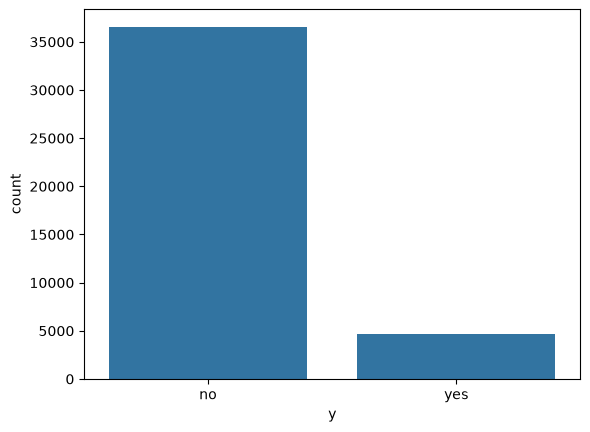

In [9]:
sns.countplot(x="y",data=bank_df)  # ye graph meeasy way me samj sakte hai ki "no" ke jayada hai "yes " ke kaam hai

Text(0.5, 1.0, 'Age Distribution of Bank Customers')

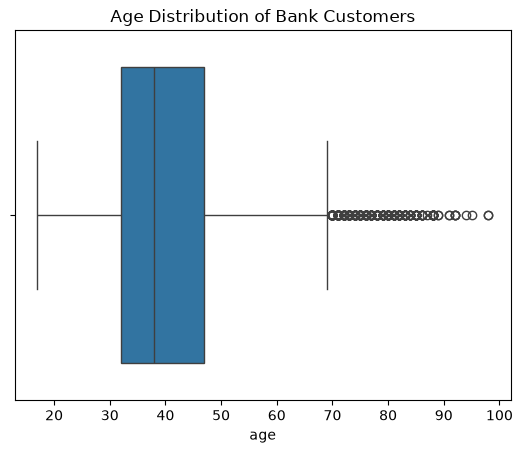

In [14]:
#                                                            Task - 3
sns.boxplot(x="age", data=bank_df)  
plt.title("Age Distribution of Bank Customers") # graph ke upper header dekhe ga


In [28]:
#                                                                   Task- 4
education_data = pd.crosstab(bank_df["education"],bank_df["y"],normalize="index") * 100  #education_data["yes"] sirf subscription accept karne walon ka percentage deta hai.
yes_percentage = education_data["yes"]
print(yes_percentage)

education
basic.4y               10.249042
basic.6y                8.202443
basic.9y                7.824648
high.school            10.835523
illiterate             22.222222
professional.course    11.348465
university.degree      13.724523
unknown                14.500289
Name: yes, dtype: float64


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'basic.4y'),
  Text(1, 0, 'basic.6y'),
  Text(2, 0, 'basic.9y'),
  Text(3, 0, 'high.school'),
  Text(4, 0, 'illiterate'),
  Text(5, 0, 'professional.course'),
  Text(6, 0, 'university.degree'),
  Text(7, 0, 'unknown')])

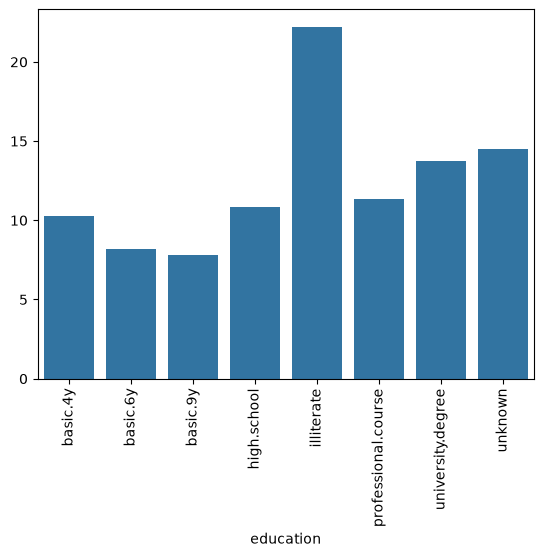

In [29]:
sns.barplot(x=yes_percentage.index, y=yes_percentage.values)
plt.xticks(rotation=90)  # bar ke naam ko 90 degree pr rotate kr diya hai


In [32]:
#                                                                 Task - 5
bank_df["age_group"] = pd.cut(
    bank_df["age"],
    bins=[0, 25, 35, 45, 60, 100],
    labels=["18-25", "26-35", "36-45", "46-60", "60+"]
)
age_data = bank_df.groupby(
    "age_group", observed=False
).apply(
    lambda x: (x["y"] == "yes").mean() * 100
).reset_index(name="percentage")


<Axes: xlabel='age_group', ylabel='percentage'>

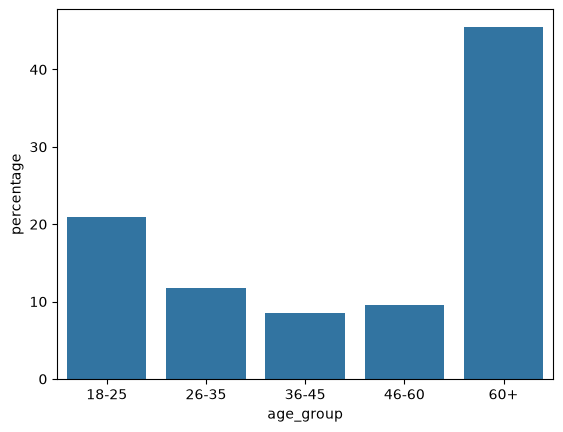

In [33]:
sns.barplot(
    data=age_data,
    x="age_group",
    y="percentage"
)